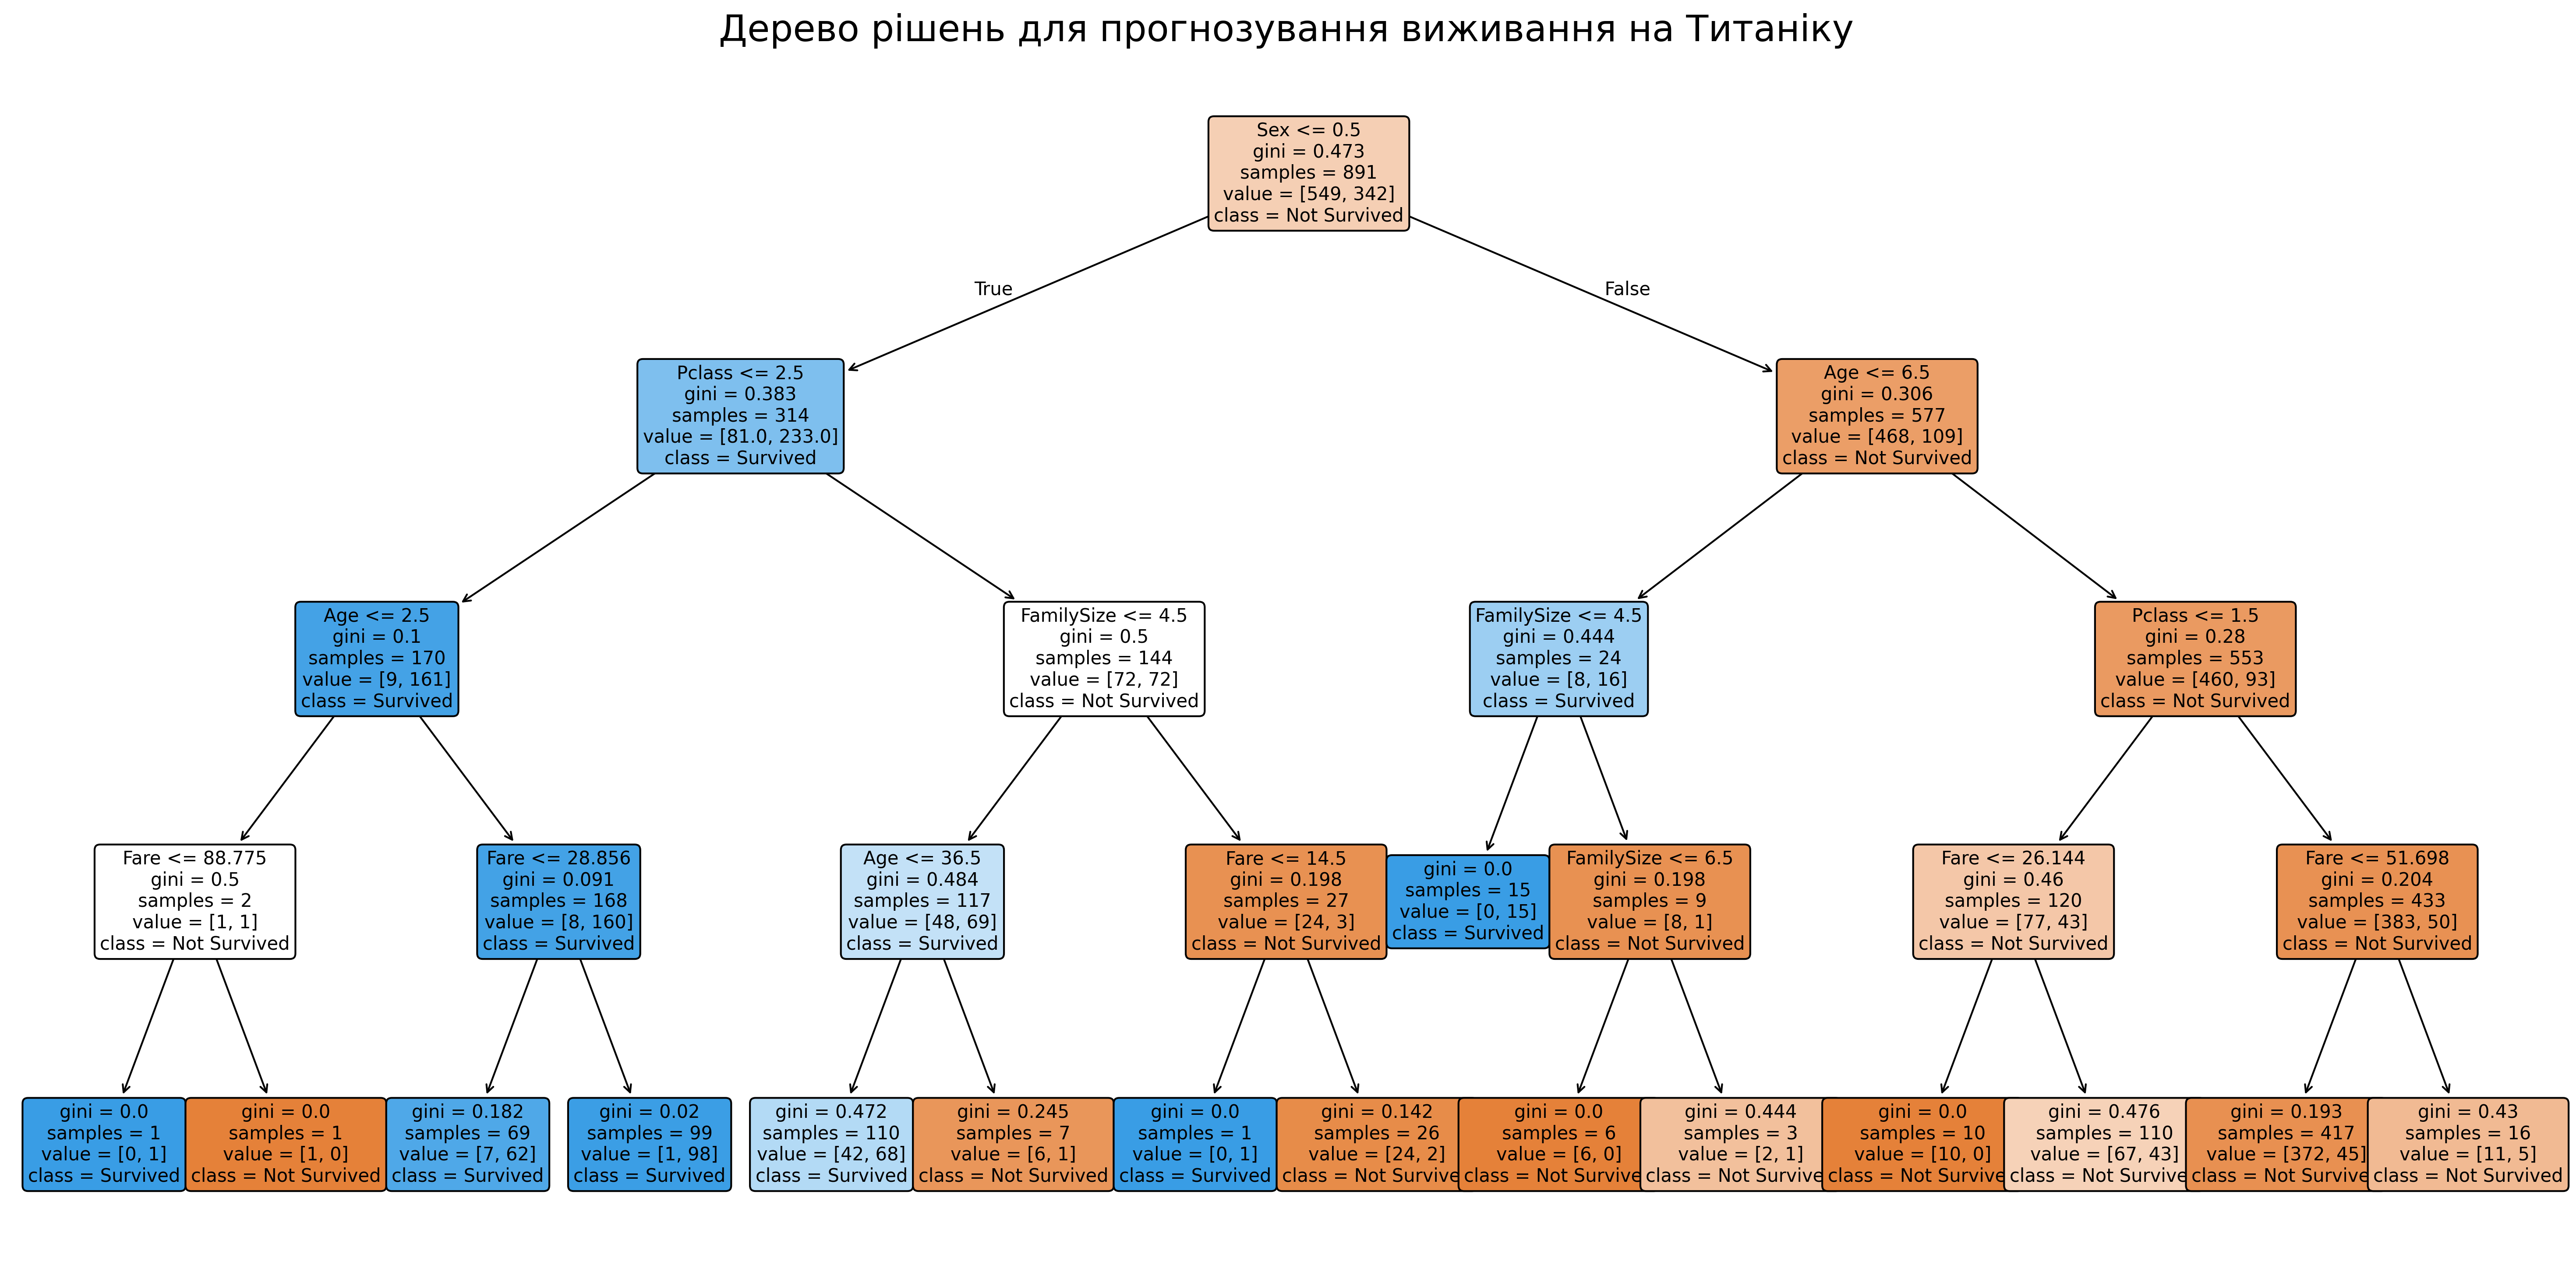

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# Обробка даних
def preprocess(df):
    # жінка = 0, чоловік = 1
    df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
    
    # розмір сім'ї
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # середнє значення
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
    
    # змінні 
    features = ['Pclass', 'Sex', 'Age', 'Fare', 'FamilySize']
    return df[features]

X_train = preprocess(train)
y_train = train['Survived']
X_test = preprocess(test)

# Дерева рішень
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Прогноз та створення файлу 
predictions = model.predict(X_test)
output = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
output.to_csv('submission.csv', index=False)

# Візуалізація
plt.figure(figsize=(25,12), dpi=300) 
plot_tree(model, 
          feature_names=X_train.columns, 
          class_names=['Not Survived', 'Survived'], 
          filled=True, 
          rounded=True, 
          impurity=True, 
          proportion=False, 
          fontsize=10)
plt.title("Дерево рішень для прогнозування виживання на Титаніку", fontsize=20)
plt.savefig('decision_tree_final.png', bbox_inches='tight') 
plt.show()
